# Import Libraries

In this step, we import all the required Python libraries.
These libraries help us load, clean, analyze, and visualize the Google Play Store dataset.

# About the Dataset

The Google Play Store dataset contains information about Android applications available on the Google Play Store.

Each row represents one application, and each column provides different details about the app.

The dataset includes information such as:

- App Name
- Category
- Rating
- Number of Reviews
- App Size
- Number of Installs
- App Type (Free or Paid)
- Price
- Content Rating
- Genre
- Last Updated Date
- Current Version
- Android Version

This dataset is used to analyze app performance, user preferences, ratings, installs, pricing, and different app categories.

# Problems Found in the Dataset

Before starting the analysis, some data quality issues were found in the dataset.

The main problems were:

1. Missing values were present in the Rating, Type, Content Rating, Current Ver, and Android Ver columns.

2. Some duplicate records were available in the dataset.

3. The Installs column contained values such as "10,000+" and "1,000,000+" instead of numeric values.

4. The Price column contained the dollar ($) symbol, so it needed to be converted into numeric format.

5. The Size column contained values like "19M", "500k", and "Varies with device", which required cleaning.

6. Some columns had incorrect data types and needed to be converted into numeric format.

7. One corrupted row contained incorrect values (for example, "Everyone" in the Price column), which had to be removed.

These issues were cleaned before performing data analysis.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load Dataset

#Now we load the Google Play Store dataset into a pandas DataFrame.
#This dataset contains information about Android applications such as category, rating, installs, price, and reviews.

In [4]:
playstore = pd.read_csv("googleplaystore.csv")

In [8]:
playstore.head()
# Display First Five Rows

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [29]:
playstore.head(15)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up



*The head() function shows the first five rows of the dataset.*

*It helps us understand the structure of the data.*

In [16]:
# check the shape 
playstore.shape


(10841, 13)

### Observation

The dataset contains **10,841 rows** and **13 columns**.

Each row represents one Android application, and each column contains specific information about that application.

In [18]:
# check  data infomantion
playstore.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


### Observation

The dataset contains both numerical and categorical columns.

Some columns have missing values.

The data types include integer, float, and object.

This information helps us identify which columns need data cleaning.

In [20]:
playstore.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


#### Check duplicate  Values

In [22]:
playstore.duplicated().sum()

483

### Observation

483 duplicate values in the dataset

The dataset contains duplicate records.

These duplicate rows should be removed to improve data quality and avoid biased analysis.

### Check Missing Values

In [27]:
playstore.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

### Observation

The dataset contains missing values in some columns.

- Rating has the highest number of missing values.
- Type has a few missing values.
- Content Rating has a few missing values.
- Current Ver and Android Ver also contain missing values.

These missing values should be handled before analysis and model building.

In [38]:
#Display Duplicate Rows

playstore[playstore.duplicated()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",Free,0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",Free,0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up


- ### Remove Duplicate Values
-  
Duplicate rows are removed to improve the quality of the dataset.

In [48]:

playstore.drop_duplicates(inplace=True)

In [50]:
playstore.duplicated().sum()

0

### Observation

- *All duplicate rows have been removed successfully.*

- *The dataset is now cleaner and ready for further analysis.*

#### Missing values handle

# Handle Missing Values - Rating

- *The Rating column is a numerical column.*

- *Missing values are replaced with the mean (average) value.*

In [57]:
# Fill numerical column with mean
playstore["Rating"] = playstore["Rating"].fillna(playstore["Rating"].mean())

# Fill categorical columns with mode
columns = ["Type", "Content Rating", "Current Ver", "Android Ver"]

for col in columns:
    playstore[col] = playstore[col].fillna(playstore[col].mode()[0])

In [59]:
playstore.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

### Observation

All missing values have been filled successfully.

- *The missing values in the Rating column were replaced with the mean value.*
- *The missing values in Type, Content Rating, Current Ver, and Android Ver were replaced with their most frequent value (mode)*

Now the dataset has no missing values and is ready for data cleaning and analysis.

# Clean Installs Column

- The Installs column contains commas (,) and plus (+) signs.

- These characters are removed so that the values can be converted into numbers.

In [72]:
playstore[playstore["Price"] == "Everyone"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,Everyone,"February 11, 2018",1.0.19,4.0 and up,4.1 and up


In [74]:
playstore = playstore.drop(10472)

In [78]:
playstore[playstore["Price"] == "Everyone"].index

Index([], dtype='int64')

In [84]:
playstore["Installs"] = playstore["Installs"].str.replace(",", "")
playstore["Installs"] = playstore["Installs"].str.replace("+", "", regex=False)
playstore["Installs"] = playstore["Installs"].astype(int)

In [86]:
print(playstore["Price"].dtype)

float64


In [88]:
print(playstore["Installs"].dtype)

int32


In [90]:
playstore.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [92]:
playstore.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10356 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10356 non-null  object 
 1   Category        10356 non-null  object 
 2   Rating          10356 non-null  float64
 3   Reviews         10356 non-null  object 
 4   Size            10356 non-null  object 
 5   Installs        10356 non-null  int32  
 6   Type            10356 non-null  object 
 7   Price           10356 non-null  float64
 8   Content Rating  10356 non-null  object 
 9   Genres          10356 non-null  object 
 10  Last Updated    10356 non-null  object 
 11  Current Ver     10356 non-null  object 
 12  Android Ver     10356 non-null  object 
dtypes: float64(2), int32(1), object(10)
memory usage: 1.1+ MB


### Category analysis

-  Count Apps in Each Category

In [99]:
# Count number of apps in each category
category_count = playstore["Category"].value_counts()

category_count

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          123
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64

**This output shows the total number of apps in each category of the Google Play Store.**

- *The FAMILY category has the highest number of apps (1943).*
- *The GAME category has 1121 apps.*
- **The TOOLS category has ***843*** apps.**
- *The BEAUTY category has the lowest number of apps (53).*

- *This means the FAMILY category is the most saturated because it contains the largest number of applications.*


### Bar Chart

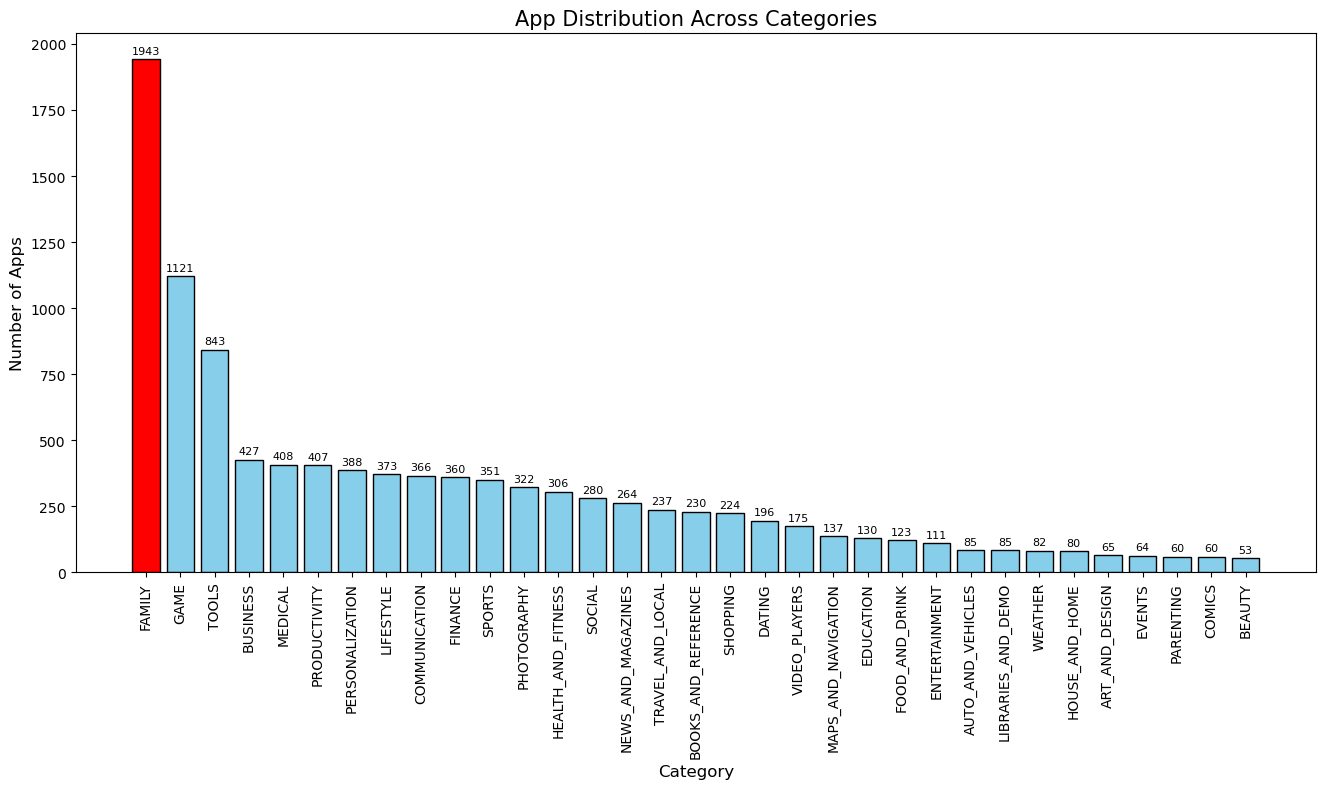

In [104]:
import matplotlib.pyplot as plt

category_count = playstore["Category"].value_counts()

colors = ["skyblue"] * len(category_count)
colors[0] = "red"

plt.figure(figsize=(16,7))

bars = plt.bar(
    category_count.index,
    category_count.values,
    color=colors,
    edgecolor="black"
)

# Value on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        int(bar.get_height()),
        ha="center",
        fontsize=8
    )

plt.xticks(rotation=90)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Number of Apps", fontsize=12)
plt.title("App Distribution Across Categories", fontsize=15)

plt.show()

This bar chart shows the number of apps available in each Google Play Store category.

- *The red bar represents the FAMILY category.*

- *It is the tallest bar because it contains the highest number of apps (1943).*

- *The blue bars represent all other categories.*

- *The GAME and TOOLS categories also have many apps.*

- *UThe BEAUTY category has the shortest bar, which means it has the lowest number of apps.*

        OR
"This graph shows the distribution of apps across different categories. The red bar represents the FAMILY category, which has the highest number of apps (1943). This makes it the most saturated category. GAME and TOOLS also contain many apps. The BEAUTY category has the fewest apps, which means competition is lower in that category."

## Ratings analysis

#### Distribution of App Ratings

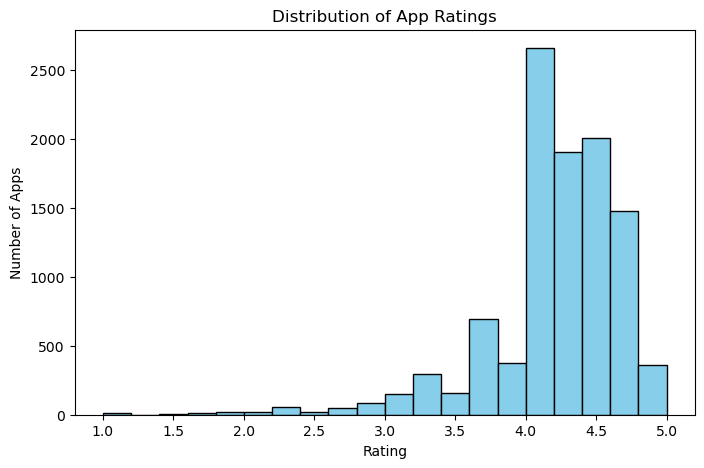

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(playstore["Rating"], bins=20, color="skyblue", edgecolor="black")

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

The histogram of app ratings shows how ratings are spread across all applications in the Google Play Store. The highest bar is between 4.0 and 4.5, which means most apps have ratings in this range.

This tells us that a large number of apps are rated positively by users. It also shows that users generally give good feedback to apps, and only a small number of apps have low ratings.

### Average Rating by Category

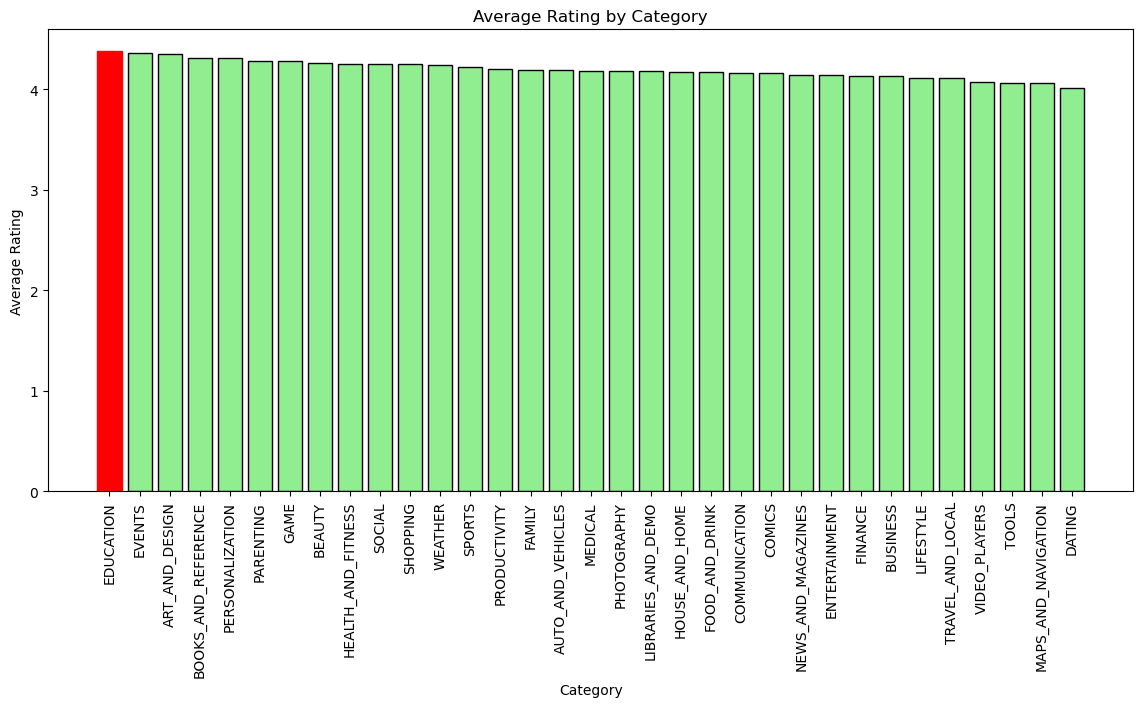

In [120]:
import matplotlib.pyplot as plt

avg_rating = playstore.groupby("Category")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(14,6))

bars = plt.bar(avg_rating.index,
               avg_rating.values,
               color="lightgreen",
               edgecolor="black")

bars[0].set_color("red")

plt.xticks(rotation=90)

plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.title("Average Rating by Category")

plt.show()

This graph shows the average rating by category.

- *Most of the bars appear to be almost equal in height, which means there is very little difference in the average ratings across categories.*

- *The green bars are nearly at the same level.*
- *The red bar is slightly taller, which means that category has a marginally higher average rating than the others.*
- *Overall, the graph suggests that most app categories have similar average ratings.*

- *The main conclusion is that there is no major variation in ratings across categories.*
- *This means users rate apps from different categories at almost the same level.*

### Size and Installs Analysis

In [123]:
#Size Column Clean
import numpy as np

playstore["Size"] = playstore["Size"].replace("Varies with device", np.nan)

playstore["Size"] = playstore["Size"].str.replace("M", "", regex=False)
playstore["Size"] = playstore["Size"].str.replace("k", "", regex=False)

playstore["Size"] = pd.to_numeric(playstore["Size"], errors="coerce")


#### scatter plot 

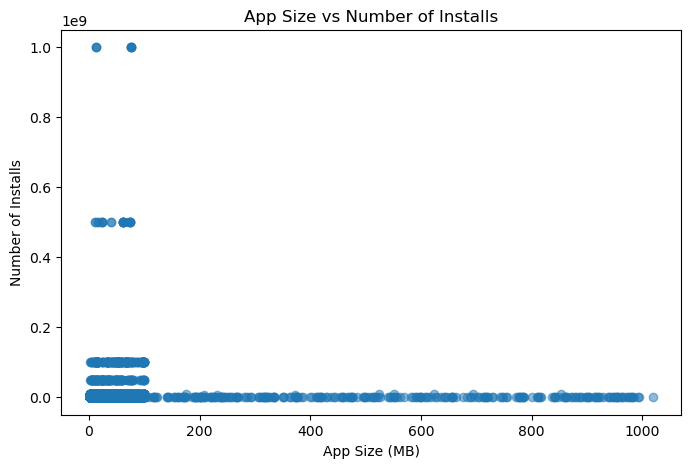

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    playstore["Size"],
    playstore["Installs"],
    alpha=0.5
)

plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")
plt.title("App Size vs Number of Installs")

plt.show()

### Scatter Plot Analysis

This scatter plot shows the relationship between app size and number of installs.

- X-axis represents App Size (MB).
- Y-axis represents Number of Installs.
- Each dot represents one app.

The graph shows that both small and large apps can have different numbers of installs.

Some small apps have very high installs, while many large apps have fewer installs.

This means app size alone does not decide how many installs an app will get.

Other factors such as app quality, rating, category, and popularity also affect installs.

#### Pricing Analysis

#### Paid vs Free Apps

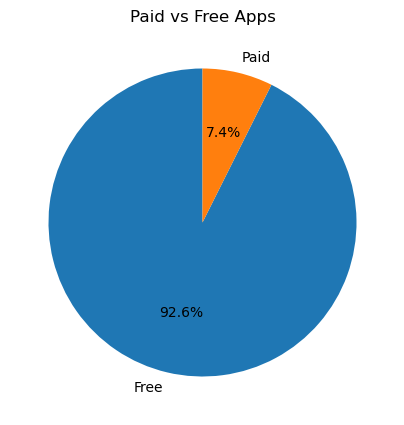

In [134]:
type_count = playstore["Type"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    type_count,
    labels=type_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Paid vs Free Apps")

plt.show()

 The pie chart shows the distribution of Free and Paid applications.

- *Most applications on the Google Play Store are Free*.

- *Only a small percentage of applications are Paid.*

- *This indicates that developers generally prefer the free app model.*

### Price Distribution

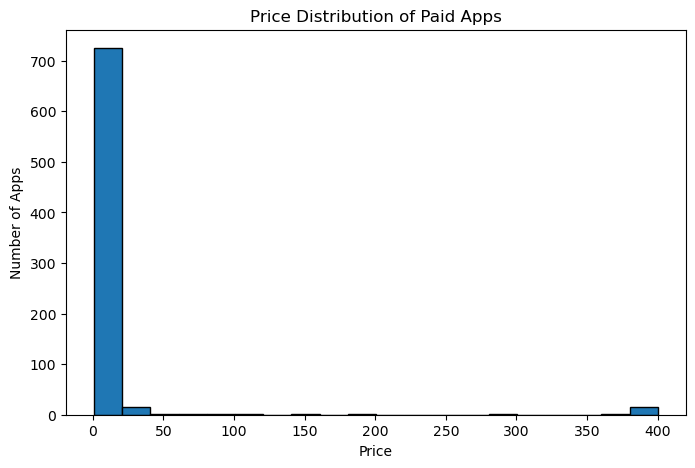

In [140]:
paid_apps = playstore[playstore["Type"]=="Paid"]

plt.figure(figsize=(8,5))

plt.hist(
    paid_apps["Price"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Price")
plt.ylabel("Number of Apps")
plt.title("Price Distribution of Paid Apps")

plt.show()

Price Distribution of Paid Apps

This histogram shows the distribution of prices of paid apps.


The X-axis represents the app price.

The Y-axis represents the number of paid apps.

Observation

Most paid apps have low prices (below $20).

Only a few apps have very high prices.

As the price increases, the number of apps decreases.

The graph is positively (right) skewed, which means most apps are low-priced while only a few are expensive.

Conclusion

Is graph se pata chalta hai ki Play Store me zyada tar paid apps ki price low hai.

High-price apps bahut kam hain. Isliye users ko mostly affordable paid apps milti hain

### Revenue Estimate by Category

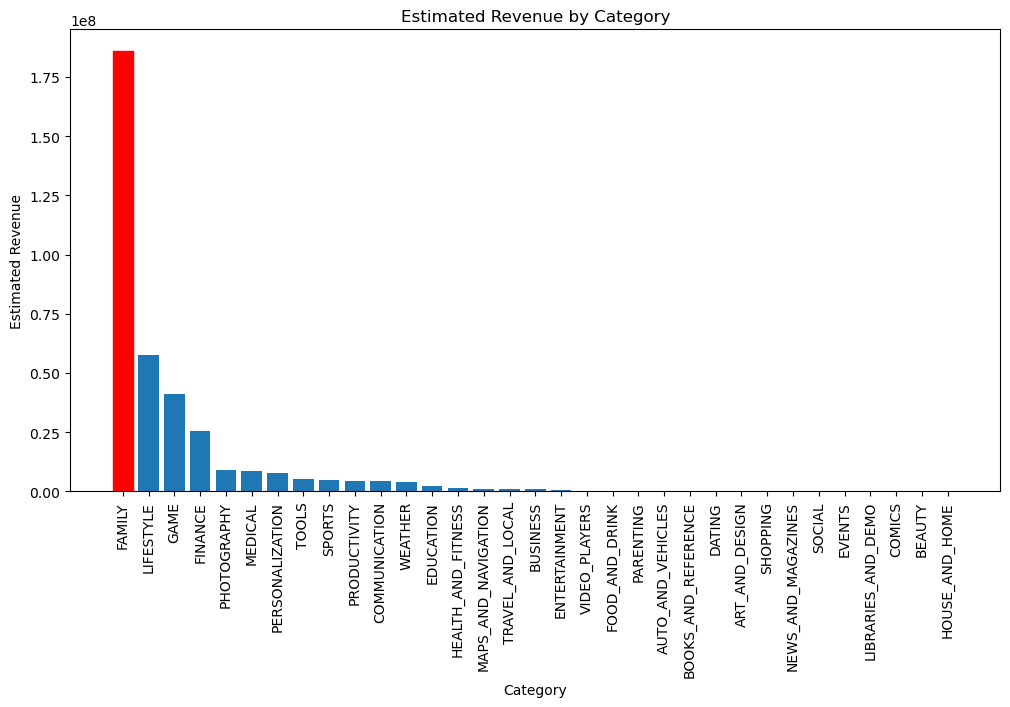

In [144]:
playstore["Revenue"] = playstore["Price"] * playstore["Installs"]

revenue = playstore.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

bars = plt.bar(revenue.index, revenue.values)

bars[0].set_color("red")

plt.xticks(rotation=90)

plt.xlabel("Category")
plt.ylabel("Estimated Revenue")
plt.title("Estimated Revenue by Category")

plt.show()

### Estimated Revenue by Category

- *This bar chart shows the estimated revenue generated by each app category.*

- *The X-axis represents different app categories.*
- *The Y-axis represents the estimated revenue.*
- **Observation**
- *The FAMILY category has the highest estimated revenue.*
- *LIFESTYLE, GAME, and FINANCE also generate high revenue.*
- *Categories such as BEAUTY, COMICS, and HOUSE_AND_HOME have very low estimated revenue.*

- *The height of each bar represents the estimated earning of that category.*

**Conclusion**

The chart shows that the FAMILY category generates the highest estimated revenue, while categories like BEAUTY, COMICS, and HOUSE_AND_HOME generate the lowest estimated revenue. This indicates that some categories are more profitable than others